# Tale of Two Sonnets: On LLM Token Burn, Effort, and Compression


<a href="https://www.kaggle.com/code/addarm/tale_of_two_sonnets" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


![The Sonnets - OpenAI 2026](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/tale_of_two_sonnets_banner.png)

This is a short follow-up to [the caveman critique piece](https://medium.com/hecatus-research/less-is-more-for-llms-a-critique-of-prompt-based-compression-910978d8bad4), after the announced release of Sonnet v5 from anthropic. 

That piece tested prompt-based output compression on a local proxy model, because the actual target of the claims, frontier RLHF models, wasn't available to test directly. 

Here we hit real Claude models and look at what changed under the hood between Sonnet 4.6 and Sonnet 5: how each one's reasoning control param burns tokens, and whether that param even works the same way across versions.

## Setup

For this article I used BOTO and Bedrock.

In [14]:
%matplotlib inline
import json
import os
import time
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from scipy import stats
from tqdm.auto import tqdm

load_dotenv()
np.random.seed(42)

REGION = "eu-west-1"
MODEL_46 = "global.anthropic.claude-sonnet-4-6"
MODEL_5 = "global.anthropic.claude-sonnet-5"

client = boto3.client("bedrock-runtime", region_name=REGION)

In [15]:
print(f"Region: {REGION}")
print(f"Sonnet 4.6 model id: {MODEL_46}")
print(f"Sonnet 5 model id:   {MODEL_5}")

Region: eu-west-1
Sonnet 4.6 model id: global.anthropic.claude-sonnet-4-6
Sonnet 5 model id:   global.anthropic.claude-sonnet-5


## LLM Reproducibility and caching

Claude has no public seed parameter, unlike some other providers. Temperature is the only lever we get, and it's a weaker one on Sonnet 5 than on Sonnet 4.6. Sonnet 4.6 forces temperature to 1.0 whenever thinking is switched on, but accepts any value, including 0, once thinking is off. Sonnet 5 rejects `temperature=0` even on its default, no-thinking-field call path: "`temperature` is deprecated for this model." It accepts 1.0, or no temperature at all, but nothing lower. 

Adaptive reasoning runs unconditionally on Sonnet 5, whether or not you ask for it, and the model won't let you sample colder than that. So we set temperature to 0 on Sonnet 4.6 calls that aren't thinking-locked to 1.0, and leave Sonnet 5 alone. Repeated trials do the job a seed would do elsewhere: they turn a single noisy sample into a distribution.

Every experiment below caches its raw results the first time it runs live, to prevent unnecessary token burn.

In [16]:
CACHE_DIR = Path("cache_tale_of_two_sonnets")
CACHE_DIR.mkdir(exist_ok=True)
FORCE_RERUN = False


def cached_run(cache_name, run_fn):
    path = CACHE_DIR / f"{cache_name}.json"
    if path.exists() and not FORCE_RERUN:
        with open(path) as f:
            return pd.DataFrame(json.load(f))
    df = run_fn()
    with open(path, "w") as f:
        json.dump(df.to_dict(orient="records"), f, indent=1)
    return df

## Token burn across reasoning configs

The API itself changed between these two models, and that's worth reporting before any number. 

Sonnet 4.6 still accepts the older extended-thinking schema, `thinking: {type: enabled, budget_tokens: N}`, a hard token ceiling you hand the model, and it forces `temperature` to 1.0 whenever thinking is switched on. Sonnet 5 rejects that schema outright. 

Anthropic moved from a token-budget parameter to a qualitative-effort param between these two model generations. The sweep below shows the two knobs behave differently.

We test five small, checkable questions (the same ones from the caveman piece) under three reasoning configs per model. For Sonnet 4.6: thinking off, `budget_tokens=1024`, and `budget_tokens=8192`. For Sonnet 5: `effort=low`, `effort=medium`, and `effort=high`.

In [17]:
benchmark = [
    ("What is 17 * 23?", "391"),
    ("In Python, what does len([1,2,3]) return?", "3"),
    ("What HTTP status code means 'Not Found'?", "404"),
    ("What is the time complexity of binary search?", "log"),
    ("Name the HTTP method used to update a resource.", "PUT"),
]


def converse(model_id, question, system=None, extra_fields=None, temperature=None):
    kwargs = {"modelId": model_id, "messages": [{"role": "user", "content": [{"text": question}]}]}
    if system:
        kwargs["system"] = [{"text": system}]
    if extra_fields:
        kwargs["additionalModelRequestFields"] = extra_fields
    if temperature is not None:
        kwargs["inferenceConfig"] = {"temperature": temperature}
    t0 = time.time()
    resp = client.converse(**kwargs)
    latency = time.time() - t0
    usage = resp["usage"]
    text = "".join(c.get("text", "") for c in resp["output"]["message"]["content"])
    return {
        "input_tokens": usage["inputTokens"],
        "output_tokens": usage["outputTokens"],
        "total_tokens": usage["totalTokens"],
        "latency": round(latency, 2),
        "text": text,
    }

In [18]:
configs_46 = [
    ("off", None),
    ("budget_1024", {"thinking": {"type": "enabled", "budget_tokens": 1024}}),
    ("budget_8192", {"thinking": {"type": "enabled", "budget_tokens": 8192}}),
]
configs_5 = [
    ("effort_low", {"thinking": {"type": "adaptive"}, "output_config": {"effort": "low"}}),
    ("effort_medium", {"thinking": {"type": "adaptive"}, "output_config": {"effort": "medium"}}),
    ("effort_high", {"thinking": {"type": "adaptive"}, "output_config": {"effort": "high"}}),
]


def run_section1_sweep():
    rows_a = []
    for question, expected in tqdm(benchmark):
        for label, extra in configs_46:
            r = converse(MODEL_46, question, extra_fields=extra, temperature=1.0 if extra else 0)
            rows_a.append({"model": "sonnet-4.6", "config": label, "question": question, "expected": expected, **r})
        for label, extra in configs_5:
            r = converse(MODEL_5, question, extra_fields=extra, temperature=1.0)
            rows_a.append({"model": "sonnet-5", "config": label, "question": question, "expected": expected, **r})
    return pd.DataFrame(rows_a)


df_a = cached_run("section1_sweep", run_section1_sweep)

In [19]:
summary_a = (
    df_a.groupby(["model", "config"])
    .agg(
        mean_input=("input_tokens", "mean"),
        mean_output=("output_tokens", "mean"),
        mean_total=("total_tokens", "mean"),
        mean_latency=("latency", "mean"),
    )
    .round(1)
)
print(summary_a.to_string())

                          mean_input  mean_output  mean_total  mean_latency
model      config                                                          
sonnet-4.6 budget_1024          46.8        239.4       286.2           4.4
           budget_8192          46.8        220.8       267.6           3.9
           off                  17.8        209.4       227.2           4.4
sonnet-5   effort_high          19.8        300.6       320.4           8.8
           effort_low           19.8        209.0       228.8           4.2
           effort_medium        19.8        267.4       287.2           4.2


### Reading the table

Two patterns hold up across repeated runs of this sweep. 

Sonnet 5's `effort_low` is reliably the cheapest of its three levels, every time. `effort_medium` and `effort_high` land close to each other though, run after run, more like a plateau than a smooth three-step ramp: the real jump happens once, between low and medium, not twice. Effort also drags latency along with it. `effort_high` is consistently the slowest of the three, well past `effort_low`.

Sonnet 4.6's `budget_tokens` behaves less predictably. In this run, `budget_8192` burns noticeably more than `budget_1024`. In earlier runs of the same sweep, the two landed close together, or even flipped. A numeric token ceiling doesn't produce the same reliable dose-response that Sonnet 5's effort levels do, at least not on questions this easy.

Sonnet 4.6 with thinking `off` still burns a fair number of output tokens on its own. The base model likes to show its arithmetic even without an explicit reasoning mode. Most of that token cost comes from the model's baseline verbosity, the same effect the original caveman piece was built around.

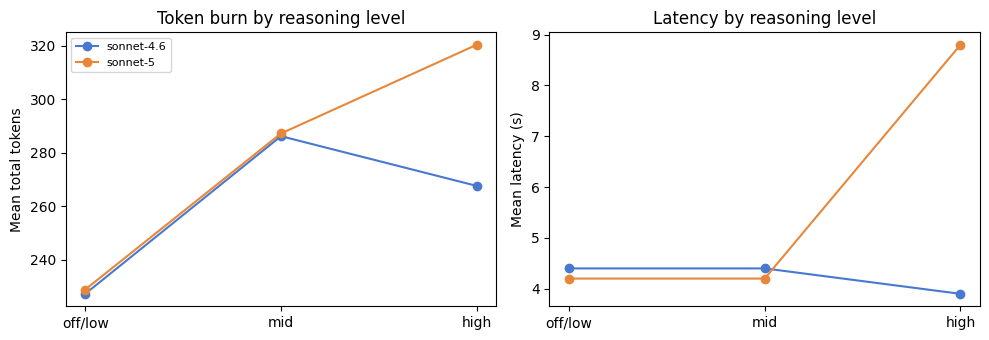

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

order = {"sonnet-4.6": ["off", "budget_1024", "budget_8192"], "sonnet-5": ["effort_low", "effort_medium", "effort_high"]}
labels = ["off/low", "mid", "high"]
colors = {"sonnet-4.6": "#4878cf", "sonnet-5": "#e8873a"}

for model, color in colors.items():
    sub = summary_a.loc[model].reindex(order[model])
    axes[0].plot(range(len(sub)), sub["mean_total"], marker="o", label=model, color=color)
    axes[1].plot(range(len(sub)), sub["mean_latency"], marker="o", label=model, color=color)

for ax, title, ylabel in [
    (axes[0], "Token burn by reasoning level", "Mean total tokens"),
    (axes[1], "Latency by reasoning level", "Mean latency (s)"),
]:
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Noisy Results?

Five questions is a thin base for calling something "noisy" versus "reliable". 

Both models are stochastic even at their most controlled settings, so we fix one question and repeat it 25 times per config, then run a two-sample t-test on total tokens. Sonnet 4.6 has no seed to lean on here since thinking forces temperature to 1.0, so 25 repeats is doing the same job a seed would elsewhere: giving us a distribution instead of a single sample.

In [21]:
N_TRIALS = 25
fixed_question, fixed_expected = benchmark[0]


def run_section1_significance():
    rows = []
    for _ in tqdm(range(N_TRIALS)):
        r = converse(MODEL_46, fixed_question, extra_fields=configs_46[1][1], temperature=1.0)
        rows.append({"model": "sonnet-4.6", "config": "budget_1024", **r})
        r = converse(MODEL_46, fixed_question, extra_fields=configs_46[2][1], temperature=1.0)
        rows.append({"model": "sonnet-4.6", "config": "budget_8192", **r})
        r = converse(MODEL_5, fixed_question, extra_fields=configs_5[0][1], temperature=1.0)
        rows.append({"model": "sonnet-5", "config": "effort_low", **r})
        r = converse(MODEL_5, fixed_question, extra_fields=configs_5[1][1], temperature=1.0)
        rows.append({"model": "sonnet-5", "config": "effort_medium", **r})
    return pd.DataFrame(rows)


df_sig1 = cached_run("section1_significance", run_section1_significance)

In [22]:
def group_tokens(model, config):
    return df_sig1[(df_sig1["model"] == model) & (df_sig1["config"] == config)]["total_tokens"].values


budget_1024 = group_tokens("sonnet-4.6", "budget_1024")
budget_8192 = group_tokens("sonnet-4.6", "budget_8192")
effort_low = group_tokens("sonnet-5", "effort_low")
effort_medium = group_tokens("sonnet-5", "effort_medium")

t_budget, p_budget = stats.ttest_ind(budget_1024, budget_8192)
t_effort, p_effort = stats.ttest_ind(effort_low, effort_medium)

print(
    f"Sonnet 4.6, budget_1024 (mean={budget_1024.mean():.1f}, sd={budget_1024.std():.1f}) vs budget_8192 (mean={budget_8192.mean():.1f}, sd={budget_8192.std():.1f})"
)
print(f"  t = {t_budget:.2f}, p = {p_budget:.3f}")
print()
print(
    f"Sonnet 5, effort_low (mean={effort_low.mean():.1f}, sd={effort_low.std():.1f}) vs effort_medium (mean={effort_medium.mean():.1f}, sd={effort_medium.std():.1f})"
)
print(f"  t = {t_effort:.2f}, p = {p_effort:.3f}")

Sonnet 4.6, budget_1024 (mean=139.7, sd=7.7) vs budget_8192 (mean=142.0, sd=0.2)
  t = -1.46, p = 0.152

Sonnet 5, effort_low (mean=77.0, sd=7.8) vs effort_medium (mean=79.2, sd=5.2)
  t = -1.15, p = 0.257


Neither difference clears p < 0.05 on this question. Sonnet 4.6's `budget_1024` versus `budget_8192` comes back at p = 0.15, and Sonnet 5's `effort_low` versus `effort_medium` at p = 0.26. Twenty-five repeats each, same arithmetic question, different configs, and both land in noise.

Averaged across five questions of different difficulty, effort looked like a dial and the budget looked flat. Pinned to one easy question and repeated enough times to check, neither param moves the needle with any confidence. 

The "reliable low-to-medium jump" in the aggregate table probably traces to the harder questions in that set, the time-complexity one especially, where more reasoning room could help. On `17 * 23`, both models already know the answer cold, and no amount of budget or effort changes how many tokens they spend saying so.

The variance itself is worth a look too. Sonnet 4.6's `budget_8192` trials came back almost identical every time (sd = 0.2 tokens), while `budget_1024` varied more (sd = 7.7). 

A bigger ceiling didn't make the model use more room. It made the model's answers more consistent, converging on the same short response every trial.

## Does caveman still compress on Sonnet 5?

Now the question we were preparing for, does Caveman still Cavemen? 

The caveman piece found that a compressed system prompt cuts output tokens sharply on frontier-style models, with no accuracy loss on a small benchmark. We check whether that holds across the version change, running baseline and caveman system prompts on both models, no thinking config override, same five questions.

In [23]:
SYSTEM_BASELINE = "You are a helpful assistant."
SYSTEM_CAVEMAN = (
    "Reply in compressed caveman speak. Rules:\n"
    "- Drop articles (a, an, the)\n"
    "- Use sentence fragments, not full sentences\n"
    "- No filler, no pleasantries, no hedging\n"
    "- Keep code blocks unchanged\n\n"
    "Example:\n"
    "User: What does a Python decorator do?\n"
    "Assistant: Wraps function. Adds behavior before/after call without modifying original. "
    "User: How does git rebase work?\n"
    "Assistant: Replays commits onto different base. Rewrites history. "
)


def run_section2_sweep():
    rows_b = []
    for question, expected in tqdm(benchmark):
        for style_label, system in [("baseline", SYSTEM_BASELINE), ("caveman", SYSTEM_CAVEMAN)]:
            for model_id, model_label in [(MODEL_46, "sonnet-4.6"), (MODEL_5, "sonnet-5")]:
                temp = 0 if model_id == MODEL_46 else None
                r = converse(model_id, question, system=system, temperature=temp)
                r["correct"] = expected.lower() in r["text"].lower()
                rows_b.append({"model": model_label, "style": style_label, "question": question, **r})
    return pd.DataFrame(rows_b)


df_b = cached_run("section2_sweep", run_section2_sweep)

In [24]:
rows = []
for model in ["sonnet-4.6", "sonnet-5"]:
    base = df_b[(df_b["model"] == model) & (df_b["style"] == "baseline")]["output_tokens"].mean()
    cave = df_b[(df_b["model"] == model) & (df_b["style"] == "caveman")]["output_tokens"].mean()
    acc_base = df_b[(df_b["model"] == model) & (df_b["style"] == "baseline")]["correct"].mean()
    acc_cave = df_b[(df_b["model"] == model) & (df_b["style"] == "caveman")]["correct"].mean()
    rows.append(
        {
            "model": model,
            "baseline_mean_out": round(base, 1),
            "caveman_mean_out": round(cave, 1),
            "compression": f"{1 - cave / base:.1%}",
            "baseline_accuracy": acc_base,
            "caveman_accuracy": acc_cave,
        }
    )

print(pd.DataFrame(rows).to_string(index=False))

     model  baseline_mean_out  caveman_mean_out compression  baseline_accuracy  caveman_accuracy
sonnet-4.6              172.6              10.0       94.2%                1.0               1.0
  sonnet-5              226.4              20.0       91.2%                1.0               1.0


Caveman still compresses on both models, heavily, but the ratio is smaller on Sonnet 5 than on Sonnet 4.6!

Sonnet 5 resists the fragment-and-drop-articles instruction a bit more than its predecessor: it keeps writing more caveman-style prose than 4.6 does under the same rules. 

It remains a compressor on the newer model, just a weaker one. Accuracy holds at the same level under both prompt styles here, but this is the same five-question benchmark from the original piece. Read it as a sanity check, not a general claim about accuracy.

### Is Sonnet 5 too Much for Caveman?

Same logic as before. 

Five questions isn't enough to call one 91% and one 95% meaningfully different, so we fix a question and run 25 trials per model per prompt style at temperature 0, then t-test the caveman output-token counts against each other, and against each model's own baseline.

In [25]:
def run_section2_significance():
    rows = []
    for _ in tqdm(range(N_TRIALS)):
        for style_label, system in [("baseline", SYSTEM_BASELINE), ("caveman", SYSTEM_CAVEMAN)]:
            for model_id, model_label in [(MODEL_46, "sonnet-4.6"), (MODEL_5, "sonnet-5")]:
                temp = 0 if model_id == MODEL_46 else None
                r = converse(model_id, fixed_question, system=system, temperature=temp)
                rows.append({"model": model_label, "style": style_label, **r})
    return pd.DataFrame(rows)


df_sig2 = cached_run("section2_significance", run_section2_significance)

In [26]:
def group_out(model, style):
    return df_sig2[(df_sig2["model"] == model) & (df_sig2["style"] == style)]["output_tokens"].values


base_46 = group_out("sonnet-4.6", "baseline")
cave_46 = group_out("sonnet-4.6", "caveman")
base_5 = group_out("sonnet-5", "baseline")
cave_5 = group_out("sonnet-5", "caveman")

t_46, p_46 = stats.ttest_ind(base_46, cave_46)
t_5, p_5 = stats.ttest_ind(base_5, cave_5)
t_cross, p_cross = stats.ttest_ind(cave_46, cave_5)

print(f"Sonnet 4.6, baseline (mean={base_46.mean():.1f}) vs caveman (mean={cave_46.mean():.1f}): t = {t_46:.2f}, p = {p_46:.4f}")
print(f"Sonnet 5,   baseline (mean={base_5.mean():.1f}) vs caveman (mean={cave_5.mean():.1f}): t = {t_5:.2f}, p = {p_5:.4f}")
print(f"Caveman only, sonnet-4.6 (mean={cave_46.mean():.1f}) vs sonnet-5 (mean={cave_5.mean():.1f}): t = {t_cross:.2f}, p = {p_cross:.4f}")

Sonnet 4.6, baseline (mean=56.9) vs caveman (mean=5.0): t = 782.12, p = 0.0000
Sonnet 5,   baseline (mean=69.9) vs caveman (mean=33.8): t = 8.30, p = 0.0000
Caveman only, sonnet-4.6 (mean=5.0) vs sonnet-5 (mean=33.8): t = -11.31, p = 0.0000


c:\Users\adamd\conda_envs\quant\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


This one holds up. All three comparisons come back at p < 0.0001.

Caveman compresses Sonnet 4.6's output from a mean of 56.9 tokens to 5.0, and Sonnet 5's from 69.9 to 33.8, both far beyond chance with 25 trials each. And the cross-model comparison, caveman output on Sonnet 4.6 against caveman output on Sonnet 5, is itself significant at t = -11.31: Sonnet 5 is reliably weaker at compressing under this prompt, by roughly 7x on this question (33.8 tokens against 5.0).

That gap between the two sections matters. The reasoning-config differences turned out to be mostly noise on an easy question. The compression difference between model versions did not. One finding survived a real statistical check and one didn't, which is exactly the kind of thing five questions and a single pass can't tell you apart.

# Conclusion

Sonnet 5 ships a genuinely different reasoning-control API: a qualitative effort level in place of Sonnet 4.6's numeric token budget.

Whether the new params actually behave more predictably is less settled than the five-question table suggested. Averaged across five questions of mixed difficulty, Sonnet 5's effort levels moved token burn and latency more visibly than Sonnet 4.6's budget levels did. But pinned to one easy question and repeated 25 times, neither param cleared statistical significance (p = 0.26 for effort, p = 0.15 for budget). Whatever dial Sonnet 5's effort setting is, it may only show up on questions hard enough to need it. This benchmark raised the "effort behaves like a real lever" idea. It didn't confirm it.

Compression is the finding that survived the same scrutiny. It weakened across the version change but didn't disappear, and the 25-trial check agreed with the five-question table: the gap between Sonnet 4.6's and Sonnet 5's caveman output came back at p < 0.0001. Sonnet 5 resists a style instruction alone more than 4.6 does, with statistical significance.

Thanks for the read!

## References

1. Muennighoff, N., Yang, Z., Shi, W., et al. (2025). *s1: Simple test-time scaling*. [arXiv:2501.19393](https://arxiv.org/abs/2501.19393)
2. Amazon Web Services (2026). *Use an Amazon Bedrock*. [AWS Bedrock documentation](https://docs.aws.amazon.com/bedrock/latest/userguide/api-keys-use.html)
3. Companion piece: [Less is More for LLMs? A Critique of Prompt-Based Compression](https://medium.com/hecatus-research/less-is-more-for-llms-a-critique-of-prompt-based-compression-910978d8bad4)

## Github

Article is available on [Github](https://github.com/adamd1985/quant_research/blob/main/tale_of_two_sonnets.ipynb)

## Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

## CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.